# HealthData.gov - US Health System Data

This notebook demonstrates how to access US health system data from [HealthData.gov](https://healthdata.gov/), including hospital capacity, COVID-19 metrics, and vaccination data.

## Data Source
- **Provider**: US Department of Health and Human Services (HHS)
- **Coverage**: United States (all states and territories)
- **License**: Public Domain (US Government)
- **API**: Socrata Open Data API (SODA)
- **Update Frequency**: Daily to Weekly

## Available Datasets
- Hospital capacity by state
- COVID-19 patient impact
- Vaccination data
- Testing data
- Nursing home data

In [1]:
import sys
sys.path.insert(0, '../../')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

from scripts.accessors.healthdata_gov import HealthDataGovAccessor

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Initialize accessor
hdg = HealthDataGovAccessor()

## 1. List Available Datasets

In [2]:
# Display available datasets
datasets = hdg.list_datasets()
datasets

,key,dataset_id,name,description,update_frequency,url
0,hospital_capacity,g62h-syeh,COVID-19 Reported Patient Impact and Hospital ...,Hospital capacity data by state,Daily,https://healthdata.gov/dataset/g62h-syeh
1,hospital_capacity_facility,anag-cw7u,COVID-19 Reported Patient Impact and Hospital ...,Hospital capacity data by individual facility,Weekly,https://healthdata.gov/dataset/anag-cw7u
2,covid19_nursing_homes,77hq-7k3a,COVID-19 Nursing Home Data,Cases and deaths in nursing homes,Weekly,https://healthdata.gov/dataset/77hq-7k3a
3,covid19_testing,j8mb-icvb,COVID-19 Diagnostic Laboratory Testing,Testing data by state,Daily,https://healthdata.gov/dataset/j8mb-icvb
4,vaccination_state,unsk-b7fc,COVID-19 Vaccination Data by State,Vaccination progress by state,Daily,https://healthdata.gov/dataset/unsk-b7fc


## 2. Hospital Capacity Data

In [3]:
# Get hospital capacity for California (last 30 days)
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=30)).strftime("%Y-%m-%d")

print(f"Fetching CA hospital data from {start_date} to {end_date}...")

ca_hospitals = hdg.get_hospital_capacity(
    state="CA",
    date_range=(start_date, end_date)
)

print(f"Retrieved {len(ca_hospitals)} records")
ca_hospitals.head()

Fetching CA hospital data from 2026-02-17 to 2026-03-19...
Retrieved 81713 records


,state,date,critical_staffing_shortage_today_yes,critical_staffing_shortage_today_no,critical_staffing_shortage_today_not_reported,critical_staffing_shortage_anticipated_within_week_yes,critical_staffing_shortage_anticipated_within_week_no,critical_staffing_shortage_anticipated_within_week_not_reported,hospital_onset_covid,hospital_onset_covid_coverage,...,previous_day_admission_pediatric_covid_confirmed_5_11,previous_day_admission_pediatric_covid_confirmed_5_11_coverage,previous_day_admission_pediatric_covid_confirmed_unknown,previous_day_admission_pediatric_covid_confirmed_unknown_coverage,staffed_icu_pediatric_patients_confirmed_covid,staffed_icu_pediatric_patients_confirmed_covid_coverage,staffed_pediatric_icu_bed_occupancy,staffed_pediatric_icu_bed_occupancy_coverage,total_staffed_pediatric_icu_beds,total_staffed_pediatric_icu_beds_coverage
0,AR,2021-06-12,13,96,2,16,93,2,1.0,109,...,NaN,0,NaN,0,NaN,0,284.0,109,423.0,109
1,IA,2021-05-19,1,65,60,1,65,60,0.0,124,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
2,RI,2021-03-30,3,11,1,3,11,1,7.0,14,...,NaN,0,NaN,0,NaN,0,77.0,14,96.0,14
3,RI,2021-03-29,3,11,1,3,11,1,7.0,14,...,NaN,0,NaN,0,NaN,0,73.0,14,96.0,14
4,MS,2020-05-23,0,0,80,0,0,80,4.0,77,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


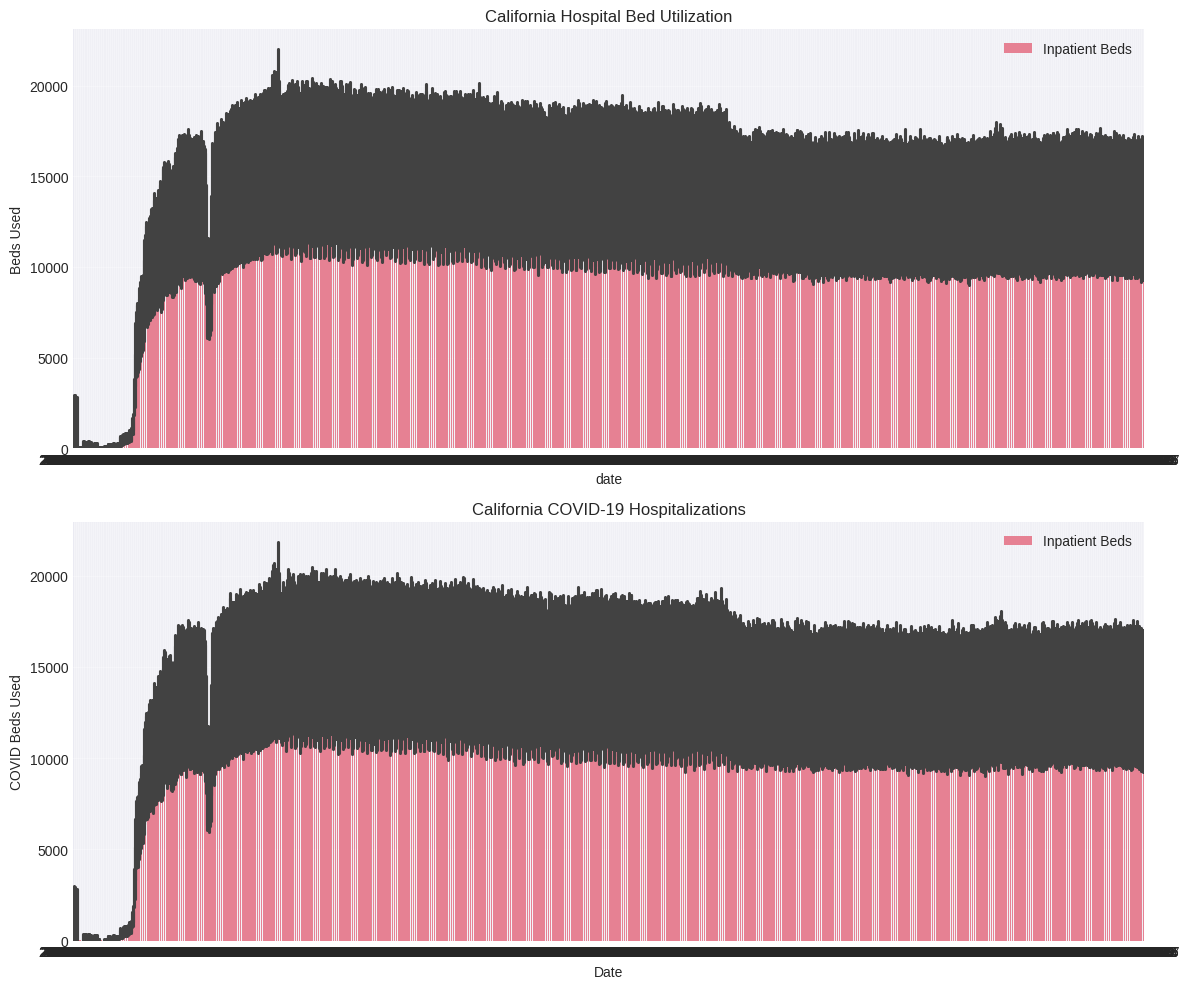

In [11]:
# Plot hospital capacity over time
if not ca_hospitals.empty and "date" in ca_hospitals.columns:
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    ca_hospitals.sort_values("date",ascending=True, inplace=True)
    
    # Total beds used
    if "inpatient_beds_used" in ca_hospitals.columns:
        sns.barplot(x=ca_hospitals["date"], y=ca_hospitals["inpatient_beds"],ax=axes[0], label="Inpatient Beds")
        # axes[0].bar(x=ca_hospitals["date"], height=ca_hospitals["inpatient_beds_used"],
        #              marker="o", linewidth=2, label="Inpatient Beds Used")
        axes[0].set_title("California Hospital Bed Utilization")
        axes[0].set_ylabel("Beds Used")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    
    # COVID beds
    if "inpatient_beds_used_covid" in ca_hospitals.columns:
        sns.barplot(x=ca_hospitals["date"], y=ca_hospitals["inpatient_beds"],ax=axes[1], label="Inpatient Beds")
        # axes[1].plot(ca_hospitals["date"], ca_hospitals["inpatient_beds_used_covid"],
        #              marker="o", color="red", linewidth=2, label="COVID Beds")
        axes[1].set_title("California COVID-19 Hospitalizations")
        axes[1].set_ylabel("COVID Beds Used")
        axes[1].set_xlabel("Date")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 3. COVID-19 Metrics

In [12]:
# Get COVID-19 metrics for New York
ny_covid = hdg.get_covid_metrics(
    state="NY",
    date_range=(start_date, end_date)
)

print(f"Retrieved {len(ny_covid)} records")
ny_covid.head()

Retrieved 81713 records


,state,date,inpatient_beds_used_covid,staffed_icu_adult_patients_confirmed_covid,total_adult_patients_hospitalized_confirmed_covid,total_pediatric_patients_hospitalized_confirmed_covid,deaths_covid
0,AR,2021-06-12,196.0,79.0,163.0,3.0,4.0
1,IA,2021-05-19,285.0,45.0,144.0,2.0,1.0
2,RI,2021-03-30,176.0,16.0,138.0,2.0,2.0
3,RI,2021-03-29,164.0,18.0,124.0,1.0,1.0
4,MS,2020-05-23,618.0,NaN,NaN,NaN,3.0


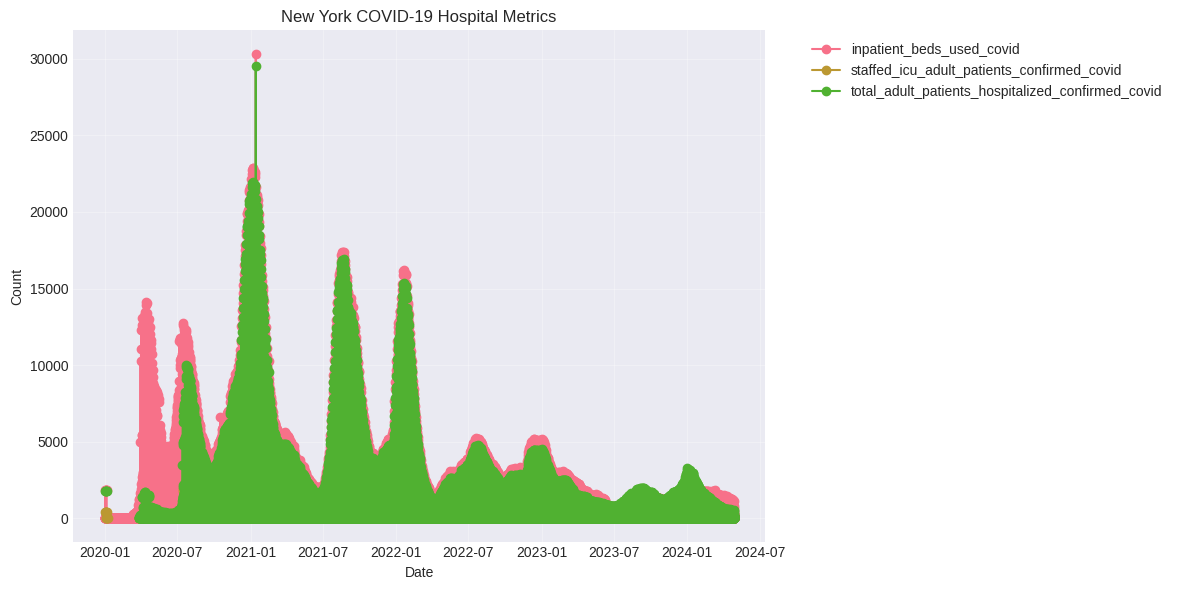

In [14]:
# Plot COVID metrics
if not ny_covid.empty:
    plt.figure(figsize=(12, 6))
    ny_covid.sort_values("date",ascending=True, inplace=True)
    
    covid_cols = [col for col in ny_covid.columns if "covid" in col.lower()]
    for col in covid_cols[:3]:  # Plot first 3 COVID metrics
        if ny_covid[col].notna().any():
            plt.plot(ny_covid["date"], ny_covid[col], marker="o", label=col)
    
    plt.title("New York COVID-19 Hospital Metrics")
    plt.xlabel("Date")
    plt.ylabel("Count")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4. State Comparison

In [15]:
# Compare hospital capacity across multiple states
states = ["CA", "TX", "NY", "FL"]

comparison = hdg.compare_states(
    states=states,
    metric="inpatient_beds_used_covid",
    date=start_date
)

comparison

,state,date,inpatient_beds_used_covid
0,CA,2024-04-27,NaN
1,TX,2024-04-27,NaN
2,NY,2024-04-27,NaN
3,FL,2024-04-27,NaN


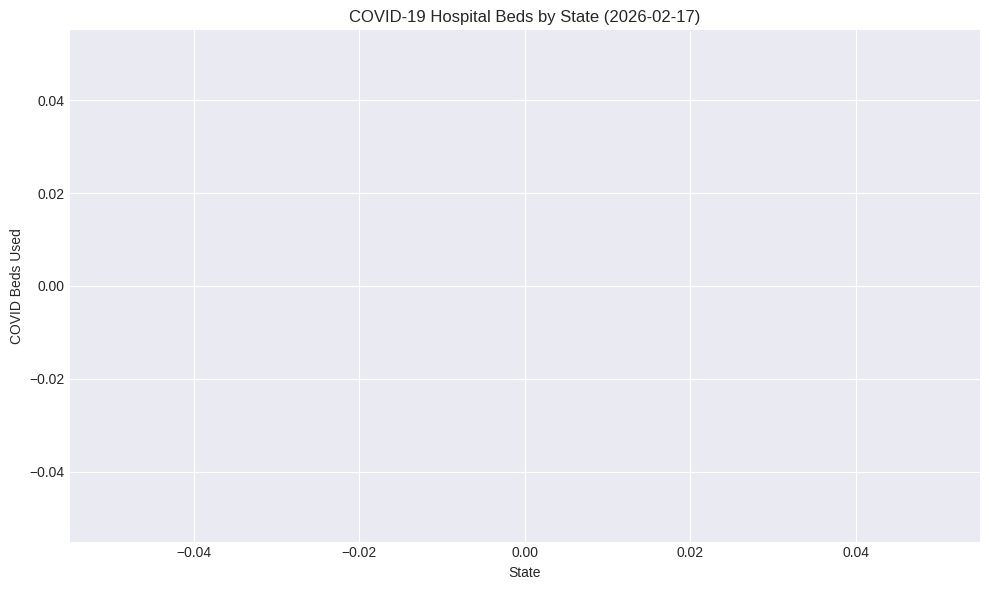

In [16]:
# Visualize state comparison
if not comparison.empty and "inpatient_beds_used_covid" in comparison.columns:
    plt.figure(figsize=(10, 6))
    
    states_clean = comparison[comparison["inpatient_beds_used_covid"].notna()]
    plt.bar(states_clean["state"], states_clean["inpatient_beds_used_covid"])
    
    plt.title(f"COVID-19 Hospital Beds by State ({start_date})")
    plt.xlabel("State")
    plt.ylabel("COVID Beds Used")
    plt.tight_layout()
    plt.show()

## 5. Current Hospital Statistics

In [17]:
# Get current stats for selected states
states = ["CA", "NY", "TX", "FL", "IL"]

current_stats = []
for state in states:
    try:
        stats = hdg.get_current_hospital_stats(state=state)
        current_stats.append(stats)
    except Exception as e:
        print(f"Error getting {state}: {e}")

stats_df = pd.DataFrame(current_stats)
stats_df

,date,state,inpatient_beds_used,inpatient_beds_used_covid,total_staffed_adult_icu_beds,staffed_icu_adult_patients_confirmed_covid
0,2024-04-27,CA,50.0,NaN,8.0,0.0
1,2024-04-27,NY,50.0,NaN,8.0,0.0
2,2024-04-27,TX,50.0,NaN,8.0,0.0
3,2024-04-27,FL,50.0,NaN,8.0,0.0
4,2024-04-27,IL,50.0,NaN,8.0,0.0


## 6. Vaccination Data

In [18]:
# Get vaccination data
vax_data = hdg.get_vaccination_data(
    state="CA",
    date_range=(start_date, end_date)
)

print(f"Retrieved {len(vax_data)} records")
vax_data.head()

RuntimeError: Failed to fetch data from https://healthdata.gov/api/views/unsk-b7fc/rows.csv?accessType=DOWNLOAD&limit=50000&%24where=location%3D%27CA%27+AND+date%3E%3D%272026-02-17%27+AND+date%3C%3D%272026-03-19%27: HTTP Error 404: Not Found

In [ ]:
# Plot vaccination progress
if not vax_data.empty:
    # Try to find relevant columns
    vax_cols = [col for col in vax_data.columns if any(x in col.lower() 
                 for x in ["dose", "series", "complete", "admin"])]
    
    if vax_cols:
        plt.figure(figsize=(12, 6))
        for col in vax_cols[:3]:
            if vax_data[col].dtype in ['int64', 'float64']:
                plt.plot(vax_data["date"], vax_data[col], marker="o", label=col[:30])
        
        plt.title("California Vaccination Progress")
        plt.xlabel("Date")
        plt.ylabel("Count")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## 7. Testing Data

In [ ]:
# Get COVID-19 testing data
testing_data = hdg.get_testing_data(
    state="NY",
    date_range=(start_date, end_date)
)

print(f"Retrieved {len(testing_data)} records")
testing_data.head()

In [ ]:
# Plot testing trends
if not testing_data.empty:
    test_cols = [col for col in testing_data.columns if any(x in col.lower() 
                  for x in ["test", "positive", "result"])]
    
    if test_cols:
        plt.figure(figsize=(12, 6))
        for col in test_cols[:2]:
            if testing_data[col].dtype in ['int64', 'float64']:
                plt.plot(testing_data["date"], testing_data[col], marker="o", label=col[:30])
        
        plt.title("New York COVID-19 Testing Data")
        plt.xlabel("Date")
        plt.ylabel("Count")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## Summary

This notebook demonstrated how to:
1. List available HealthData.gov datasets
2. Retrieve hospital capacity data by state
3. Access COVID-19 patient impact metrics
4. Compare metrics across multiple states
5. Get current hospital statistics
6. Analyze vaccination progress
7. Work with testing data

For more information, visit: https://healthdata.gov/